In [48]:
import pandas as pd

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [50]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00
Type,0,0.00
Order Profit Per Order,0,0.00
Order Item Cardprod Id,0,0.00
Order Item Discount,0,0.00
Order Item Discount Rate,0,0.00
Order Item Id,0,0.00


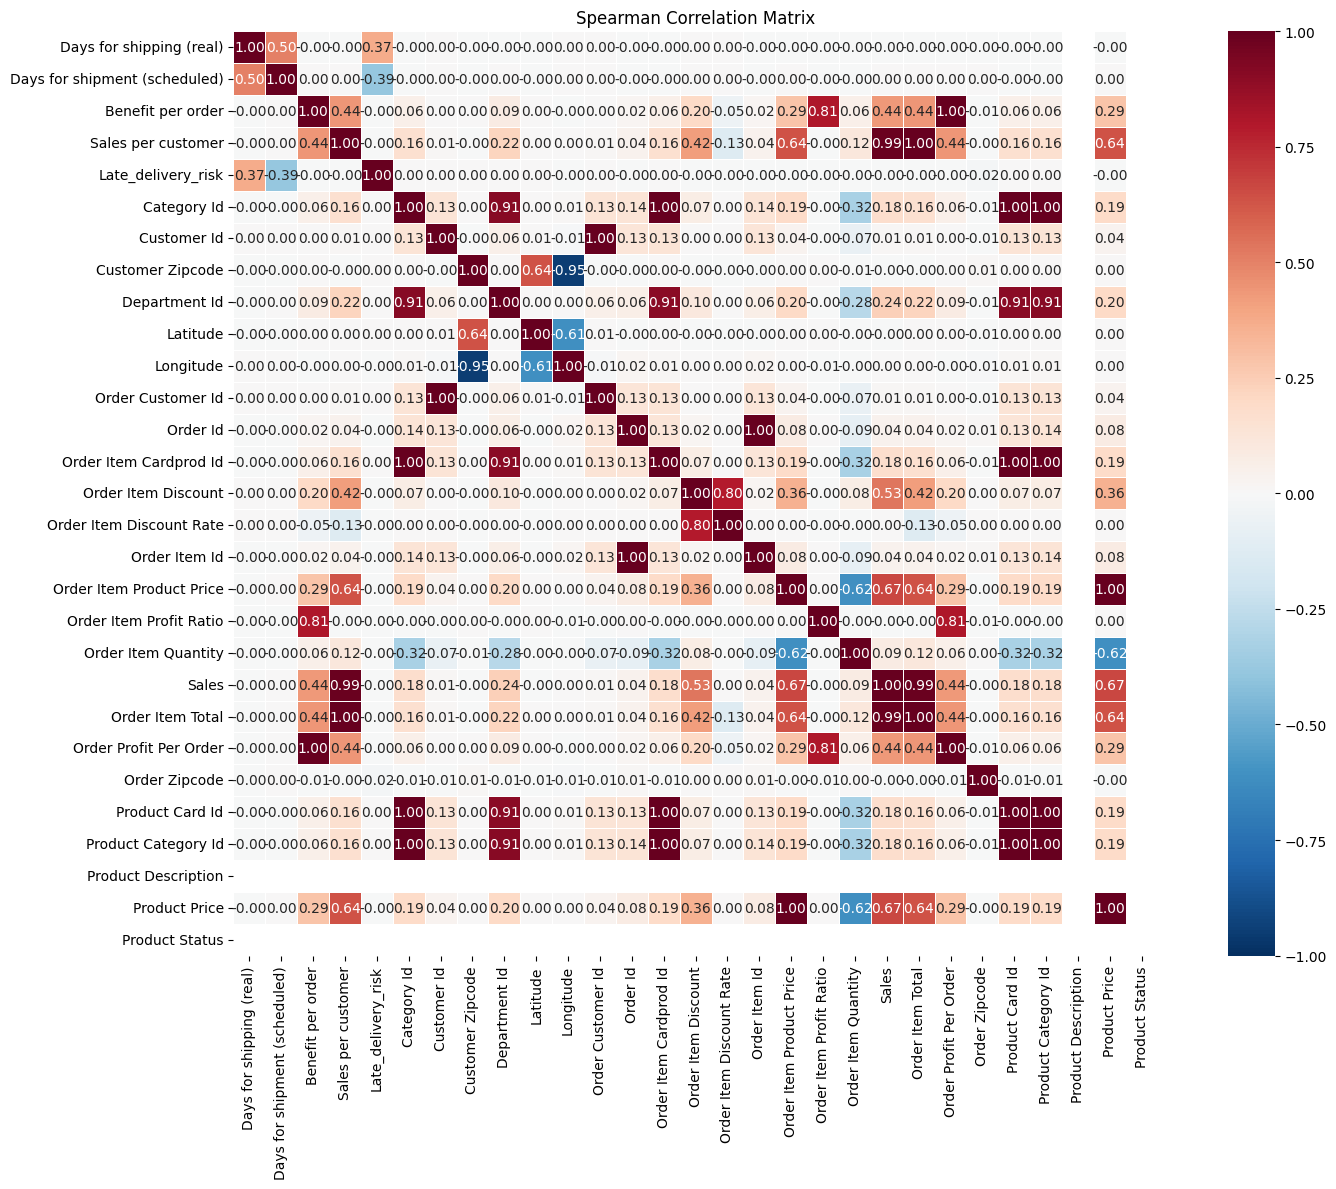

In [51]:
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr(method='spearman')  # spearman handles non-linear relationships better

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

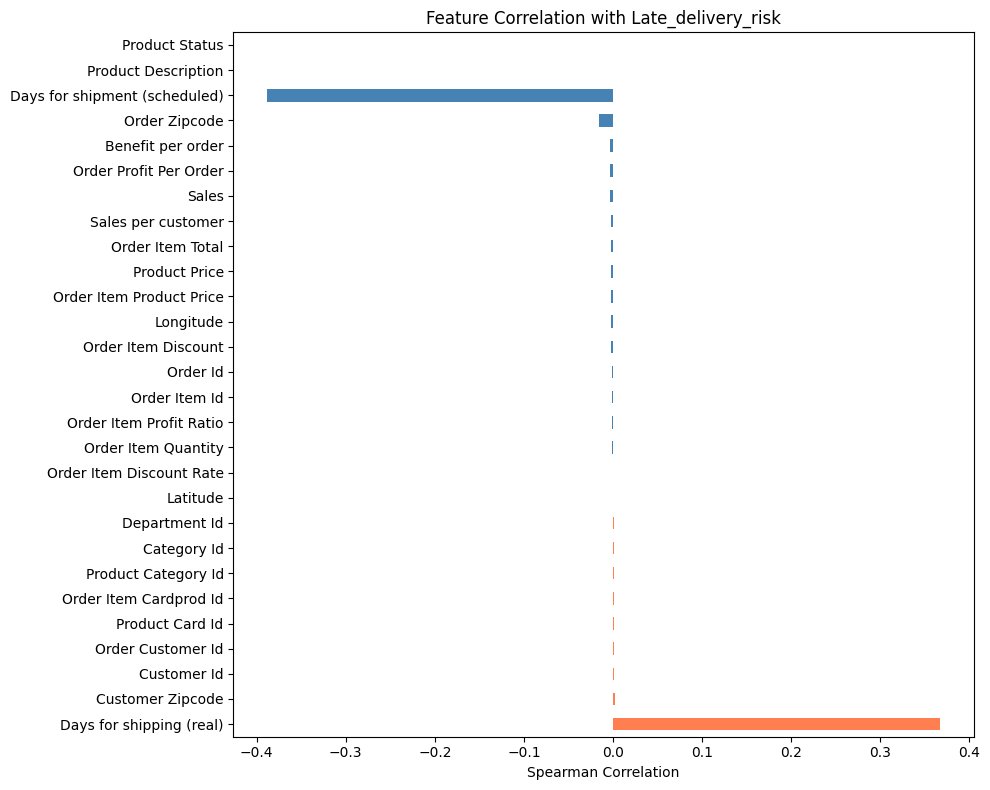

Days for shipping (real)         0.367384
Customer Zipcode                 0.002757
Customer Id                      0.001030
Order Customer Id                0.001030
Product Card Id                  0.000945
Order Item Cardprod Id           0.000945
Product Category Id              0.000945
Category Id                      0.000945
Department Id                    0.000665
Latitude                         0.000367
Order Item Discount Rate        -0.000377
Order Item Quantity             -0.000555
Order Item Profit Ratio         -0.000987
Order Item Id                   -0.001376
Order Id                        -0.001376
Order Item Discount             -0.002121
Longitude                       -0.002341
Order Item Product Price        -0.002541
Product Price                   -0.002541
Order Item Total                -0.002654
Sales per customer              -0.002654
Sales                           -0.002832
Order Profit Per Order          -0.002947
Benefit per order               -0

In [52]:
# Correlation of all numeric features with the target
target_corr = corr_matrix['Late_delivery_risk'].drop('Late_delivery_risk').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=target_corr.apply(lambda x: 'coral' if x > 0 else 'steelblue'))
plt.title('Feature Correlation with Late_delivery_risk')
plt.xlabel('Spearman Correlation')
plt.tight_layout()
plt.show()

print(target_corr)

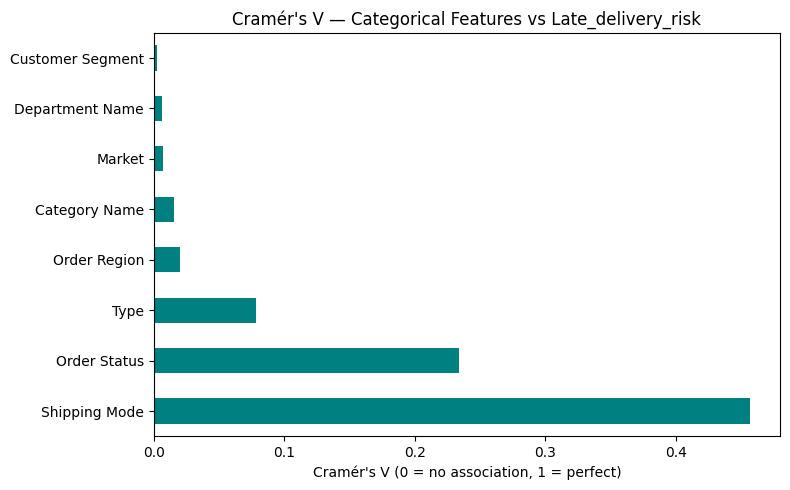

Shipping Mode       0.457090
Order Status        0.233647
Type                0.078200
Order Region        0.020374
Category Name       0.015414
Market              0.006923
Department Name     0.006077
Customer Segment    0.002383
dtype: float64


In [53]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    """Calculate Cramér's V for two categorical variables."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Categorical columns relevant to your project
cat_cols = ['Shipping Mode', 'Customer Segment', 'Market', 'Order Region',
            'Order Status', 'Category Name', 'Department Name', 'Type']

# Cramér's V of each categorical feature with the target
target_str = df['Late_delivery_risk'].astype(str)
cat_corr = {}
for col in cat_cols:
    if col in df.columns:
        cat_corr[col] = cramers_v(df[col], target_str)

cat_corr = pd.Series(cat_corr).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_corr.plot(kind='barh', color='teal')
plt.title("Cramér's V — Categorical Features vs Late_delivery_risk")
plt.xlabel("Cramér's V (0 = no association, 1 = perfect)")
plt.tight_layout()
plt.show()

print(cat_corr)


In [54]:
from scipy.stats import pointbiserialr

pb_corr = {}
for col in numeric_cols:
    if col != 'Late_delivery_risk':
        corr, pval = pointbiserialr(df['Late_delivery_risk'], df[col])
        pb_corr[col] = {'correlation': corr, 'p_value': pval}

pb_df = pd.DataFrame(pb_corr).T.sort_values('correlation', ascending=False)
print(pb_df)


                               correlation   p_value
Days for shipping (real)          0.401415  0.000000
Product Category Id               0.001752  0.456774
Category Id                       0.001752  0.456774
Order Item Cardprod Id            0.001490  0.526794
Product Card Id                   0.001490  0.526794
Customer Id                       0.001484  0.528238
Order Customer Id                 0.001484  0.528238
Department Id                     0.001077  0.647253
Latitude                          0.000679  0.772991
Order Item Discount Rate          0.000404  0.863614
Order Item Quantity              -0.000139  0.952828
Order Item Discount              -0.000750  0.750018
Order Id                         -0.001293  0.582867
Order Item Id                    -0.001376  0.558883
Longitude                        -0.001915  0.415886
Order Item Product Price         -0.002175  0.355380
Product Price                    -0.002175  0.355380
Order Item Profit Ratio          -0.002316  0.

/Users/absarkar/Developer/epoch/epoch/lib/python3.14/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [55]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1) Drop leaky/useless columns
leak_and_drop = [
    "Days for shipping (real)",
    "Delivery Status",
    "shipping date (DateOrders)",
    "Product Description",
    "Order Zipcode",
    "Customer Fname",
    "Customer Lname",
    "Customer Email",
    "Customer Password",
    "Customer Street",
    "Customer Zipcode",
    "Product Image",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Order Customer Id",
    "Product Category Id",
]
df = df.drop(columns=[c for c in leak_and_drop if c in df.columns], errors="ignore")

# 2) Time features
if "order date (DateOrders)" in df.columns:
    dt = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
    df["order_month"] = dt.dt.month
    df["order_dayofweek"] = dt.dt.dayofweek
    df["order_hour"] = dt.dt.hour
    df["order_quarter"] = dt.dt.quarter
    df = df.drop(columns=["order date (DateOrders)"], errors="ignore")

target = "Late_delivery_risk"

# 3) Order-node feature candidates (numeric only here)
order_node_features = [
    "Days for shipment (scheduled)", "Order Item Quantity", "Product Price",
    "Order Item Discount", "Order Item Discount Rate", "Order Item Product Price",
    "Order Item Total", "Sales", "Benefit per order", "Order Profit Per Order",
    "Order Item Profit Ratio", "Sales per customer", "Latitude", "Longitude",
    "order_month", "order_dayofweek", "order_hour", "order_quarter"
]
order_node_features = [c for c in order_node_features if c in df.columns]

# 4) One-hot encode low-cardinality order categoricals
order_categorical_features = ["Shipping Mode", "Type"]  # exclude Order Status to avoid leakage risk
order_categorical_features = [c for c in order_categorical_features if c in df.columns]

df_encoded = pd.get_dummies(df.copy(), columns=order_categorical_features, drop_first=False)

# 5) Label encode graph-structure columns (for node/edge mapping)
graph_node_cols = {
    "customer": "Customer Id",
    "product": "Product Card Id",
    "category": "Category Name",
    "city": "Customer City",
    "order_city": "Order City",
    "region": "Order Region",
    "market": "Market",
    "department": "Department Name",
}

le_dict = {}
for node_type, col in graph_node_cols.items():
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col + "_idx"] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[node_type] = le

# 6) Spearman filter for numeric order-node features
num_feats = [c for c in order_node_features if c in df_encoded.select_dtypes(include="number").columns]
corr_series = df_encoded[num_feats + [target]].corr(method="spearman")[target].drop(target).dropna()
corr_series = corr_series.sort_values(key=np.abs, ascending=False)

# threshold can be tuned; start with small cutoff
selected_num = corr_series[corr_series.abs() >= 0.03].index.tolist()

# add one-hot columns to final order node feature set
onehot_cols = [c for c in df_encoded.columns if any(c.startswith(f"{oc}_") for oc in order_categorical_features)]
final_order_features = selected_num + onehot_cols

print("Top Spearman correlations with target:")
print(corr_series.head(20))
print("\nSelected numeric order features:", len(selected_num))
print("Total final order-node features (numeric + one-hot):", len(final_order_features))

Top Spearman correlations with target:
Days for shipment (scheduled)   -0.388240
order_hour                       0.047052
Benefit per order               -0.002947
Order Profit Per Order          -0.002947
Sales                           -0.002832
Order Item Total                -0.002654
Sales per customer              -0.002654
order_month                      0.002601
Order Item Product Price        -0.002541
Product Price                   -0.002541
Longitude                       -0.002341
Order Item Discount             -0.002121
order_dayofweek                  0.001119
order_quarter                    0.001099
Order Item Profit Ratio         -0.000987
Order Item Quantity             -0.000555
Order Item Discount Rate        -0.000377
Latitude                         0.000367
Name: Late_delivery_risk, dtype: float64

Selected numeric order features: 2
Total final order-node features (numeric + one-hot): 10


In [56]:
from sklearn.preprocessing import LabelEncoder

# Label encode customer node attributes used later
customer_attr_cols = ["Customer Segment", "Customer Country", "Customer State"]
for col in customer_attr_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col + "_enc"] = le.fit_transform(df_encoded[col].astype(str).fillna("UNK"))

# Product Status may be non-numeric; encode if needed
if "Product Status" in df_encoded.columns and not pd.api.types.is_numeric_dtype(df_encoded["Product Status"]):
    le_ps = LabelEncoder()
    df_encoded["Product Status_enc"] = le_ps.fit_transform(df_encoded["Product Status"].astype(str).fillna("UNK"))
else:
    df_encoded["Product Status_enc"] = df_encoded.get("Product Status", 0)

In [57]:
import torch
import numpy as np
from torch_geometric.data import HeteroData
from sklearn.preprocessing import StandardScaler

# ============================================
# DEVICE SETUP — Apple M4 (MPS) / CUDA / CPU
# ============================================

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple M4 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

# ============================================
# STEP 1: PREPARE NODE FEATURES
# ============================================

# --- Order node features ---
shipping_mode_cols = [c for c in df_encoded.columns if c.startswith('Shipping Mode_')]
type_cols = [c for c in df_encoded.columns if c.startswith('Type_')]
order_status_cols = [c for c in df_encoded.columns if c.startswith('Order Status_')]

all_order_feature_cols = order_node_features + shipping_mode_cols + type_cols + order_status_cols

scaler = StandardScaler()
order_features_np = scaler.fit_transform(df_encoded[all_order_feature_cols].fillna(0).values)
order_features = torch.tensor(order_features_np, dtype=torch.float)
labels = torch.tensor(df_encoded['Late_delivery_risk'].values, dtype=torch.long)

print(f"Order nodes: {order_features.shape[0]}, Features: {order_features.shape[1]}")

# --- Customer node features ---
customer_cols = ["Customer Segment_enc", "Customer Country_enc", "Customer State_enc", "Latitude", "Longitude"]
customer_cols = [c for c in customer_cols if c in df_encoded.columns]

customer_df = df_encoded.groupby("Customer Id_idx")[customer_cols].first().reset_index()
customer_features = torch.tensor(
    StandardScaler().fit_transform(customer_df[customer_cols].fillna(0).values),
    dtype=torch.float
)
print(f"Customer nodes: {customer_features.shape[0]}, Features: {customer_features.shape[1]}")

# --- Product node features ---
prod_cols = ["Product Price", "Product Status_enc", "Category Id", "Department Id"]
prod_cols = [c for c in prod_cols if c in df_encoded.columns]

product_df = df_encoded.groupby("Product Card Id_idx")[prod_cols].first().reset_index()
product_features = torch.tensor(
    StandardScaler().fit_transform(product_df[prod_cols].fillna(0).values),
    dtype=torch.float
)
print(f"Product nodes: {product_features.shape[0]}, Features: {product_features.shape[1]}")

# --- City node features ---
city_df = df_encoded.groupby('Customer City_idx').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
}).reset_index()

city_features = torch.tensor(
    StandardScaler().fit_transform(city_df[['Latitude', 'Longitude']].values),
    dtype=torch.float
)
print(f"City nodes: {city_features.shape[0]}, Features: {city_features.shape[1]}")

# --- Category & Region node features ---
num_categories = df_encoded['Category Name_idx'].nunique()
category_features = torch.eye(num_categories, dtype=torch.float)
print(f"Category nodes: {num_categories}")

num_regions = df_encoded['Order Region_idx'].nunique()
region_features = torch.eye(num_regions, dtype=torch.float)
print(f"Region nodes: {num_regions}")


# ============================================
# STEP 2: BUILD EDGE INDICES
# ============================================

def build_edge_index(src_col, dst_col):
    src = torch.tensor(df_encoded[src_col].values, dtype=torch.long)
    dst = torch.tensor(df_encoded[dst_col].values, dtype=torch.long)
    return torch.stack([src, dst], dim=0)

df_encoded['order_idx'] = np.arange(len(df_encoded))

customer_to_order = build_edge_index('Customer Id_idx', 'order_idx')
order_to_customer = build_edge_index('order_idx', 'Customer Id_idx')

product_to_order = build_edge_index('Product Card Id_idx', 'order_idx')
order_to_product = build_edge_index('order_idx', 'Product Card Id_idx')

city_customer = df_encoded[['Customer City_idx', 'Customer Id_idx']].drop_duplicates()
city_to_customer = torch.tensor(city_customer.values.T, dtype=torch.long)
customer_to_city = torch.tensor(city_customer[['Customer Id_idx', 'Customer City_idx']].values.T, dtype=torch.long)

cat_product = df_encoded[['Category Name_idx', 'Product Card Id_idx']].drop_duplicates()
category_to_product = torch.tensor(cat_product.values.T, dtype=torch.long)
product_to_category = torch.tensor(cat_product[['Product Card Id_idx', 'Category Name_idx']].values.T, dtype=torch.long)

region_to_order = build_edge_index('Order Region_idx', 'order_idx')
order_to_region = build_edge_index('order_idx', 'Order Region_idx')

print(f"\nEdge counts:")
print(f"  customer <-> order:   {customer_to_order.shape[1]}")
print(f"  product <-> order:    {product_to_order.shape[1]}")
print(f"  city <-> customer:    {city_to_customer.shape[1]}")
print(f"  category <-> product: {category_to_product.shape[1]}")
print(f"  region <-> order:     {region_to_order.shape[1]}")


# ============================================
# STEP 3: ASSEMBLE HETERODATA OBJECT
# ============================================

data = HeteroData()

data['order'].x = order_features
data['order'].y = labels
data['customer'].x = customer_features
data['product'].x = product_features
data['city'].x = city_features
data['category'].x = category_features
data['region'].x = region_features

data['customer', 'places', 'order'].edge_index = customer_to_order
data['order', 'placed_by', 'customer'].edge_index = order_to_customer
data['product', 'in', 'order'].edge_index = product_to_order
data['order', 'contains', 'product'].edge_index = order_to_product
data['city', 'has', 'customer'].edge_index = city_to_customer
data['customer', 'lives_in', 'city'].edge_index = customer_to_city
data['category', 'includes', 'product'].edge_index = category_to_product
data['product', 'belongs_to', 'category'].edge_index = product_to_category
data['region', 'receives', 'order'].edge_index = region_to_order
data['order', 'shipped_to', 'region'].edge_index = order_to_region


# ============================================
# STEP 4: TRAIN/VAL/TEST SPLIT
# ============================================

num_orders = data['order'].x.shape[0]
perm = torch.randperm(num_orders)

train_end = int(0.70 * num_orders)
val_end = int(0.85 * num_orders)

train_mask = torch.zeros(num_orders, dtype=torch.bool)
val_mask = torch.zeros(num_orders, dtype=torch.bool)
test_mask = torch.zeros(num_orders, dtype=torch.bool)

train_mask[perm[:train_end]] = True
val_mask[perm[train_end:val_end]] = True
test_mask[perm[val_end:]] = True

data['order'].train_mask = train_mask
data['order'].val_mask = val_mask
data['order'].test_mask = test_mask

print(f"\nSplit: Train {train_mask.sum()}, Val {val_mask.sum()}, Test {test_mask.sum()}")


# ============================================
# STEP 5: MOVE TO DEVICE & VERIFY
# ============================================

data = data.to(device)

print("\n" + "="*50)
print("GRAPH SUMMARY")
print("="*50)
print(f"Device: {device}")
print(data)
print(f"\nNode types: {data.node_types}")
print(f"Edge types: {data.edge_types}")
print(f"Total nodes: {sum(data[nt].x.shape[0] for nt in data.node_types)}")
print(f"Total edges: {sum(data[et].edge_index.shape[1] for et in data.edge_types)}")
print(f"Target balance: {data['order'].y.float().mean():.3f} (fraction of late deliveries)")


Using Apple M4 GPU (MPS)
Order nodes: 180519, Features: 26
Customer nodes: 20652, Features: 5
Product nodes: 118, Features: 4
City nodes: 563, Features: 2
Category nodes: 50
Region nodes: 23

Edge counts:
  customer <-> order:   180519
  product <-> order:    180519
  city <-> customer:    20652
  category <-> product: 118
  region <-> order:     180519

Split: Train 126363, Val 27078, Test 27078

GRAPH SUMMARY
Device: mps
HeteroData(
  order={
    x=[180519, 26],
    y=[180519],
    train_mask=[180519],
    val_mask=[180519],
    test_mask=[180519],
  },
  customer={ x=[20652, 5] },
  product={ x=[118, 4] },
  city={ x=[563, 2] },
  category={ x=[50, 50] },
  region={ x=[23, 23] },
  (customer, places, order)={ edge_index=[2, 180519] },
  (order, placed_by, customer)={ edge_index=[2, 180519] },
  (product, in, order)={ edge_index=[2, 180519] },
  (order, contains, product)={ edge_index=[2, 180519] },
  (city, has, customer)={ edge_index=[2, 20652] },
  (customer, lives_in, city)={ edg

Model parameters: 176,193 trainable / 176,193 total
LateDeliveryHGNN(
  (input_lins): ModuleDict(
    (order): Linear(26, 64, bias=True)
    (customer): Linear(5, 64, bias=True)
    (product): Linear(4, 64, bias=True)
    (city): Linear(2, 64, bias=True)
    (category): Linear(50, 64, bias=True)
    (region): Linear(23, 64, bias=True)
  )
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=10)
  )
  (norms): ModuleList(
    (0-1): 2 x ModuleDict(
      (order): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (customer): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (product): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (city): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (category): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (region): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2):

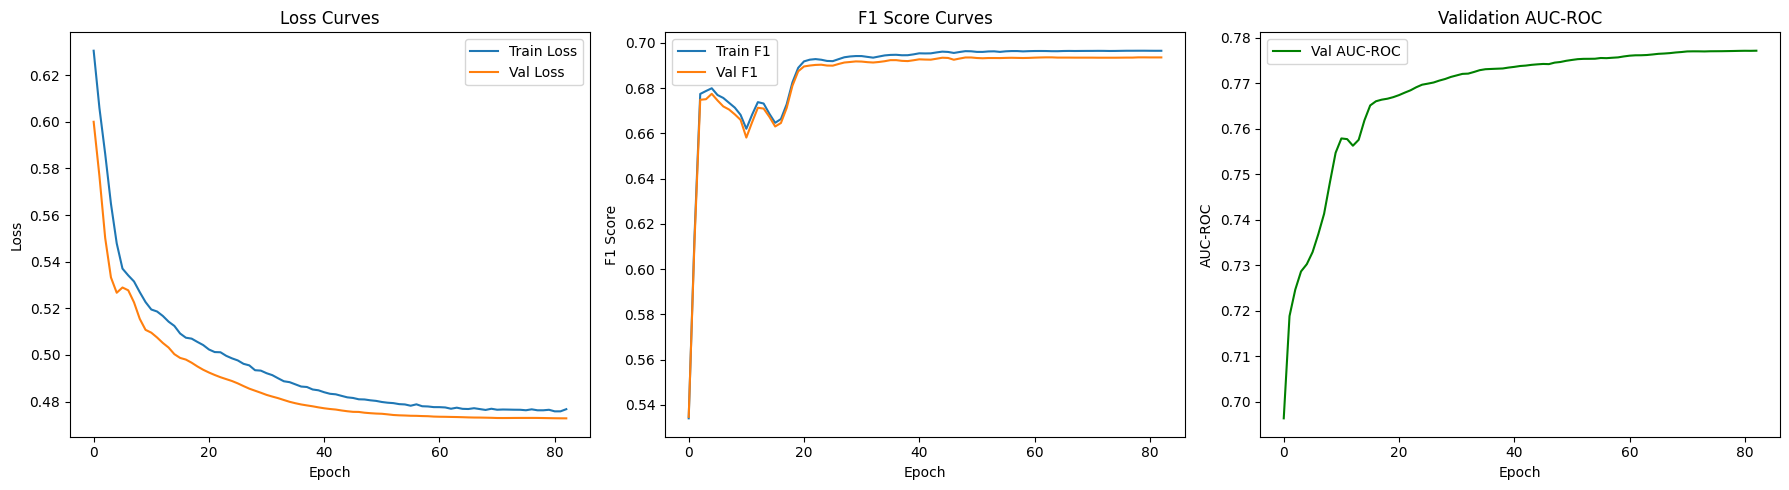

In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, Linear
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# MODEL DEFINITION
# ============================================

class LateDeliveryHGNN(nn.Module):
    def __init__(self, metadata, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout

        # Per-node-type input projections
        self.input_lins = nn.ModuleDict()
        node_dims = {
            'order': 26,
            'customer': 5,
            'product': 4,
            'city': 2,
            'category': 50,
            'region': 23,
        }
        for node_type, dim in node_dims.items():
            self.input_lins[node_type] = Linear(dim, hidden_dim)

        # Heterogeneous convolution layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            conv_dict = {}
            for edge_type in metadata[1]:
                src, rel, dst = edge_type
                conv_dict[edge_type] = SAGEConv(hidden_dim, hidden_dim)
            self.convs.append(HeteroConv(conv_dict, aggr='mean'))

            # Layer norm per node type
            norm_dict = nn.ModuleDict()
            for node_type in metadata[0]:
                norm_dict[node_type] = nn.LayerNorm(hidden_dim)
            self.norms.append(norm_dict)

        # Classifier head for order nodes
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_dict, edge_index_dict):
        # Project all node types to hidden_dim
        x_dict = {
            node_type: self.input_lins[node_type](x).relu()
            for node_type, x in x_dict.items()
        }

        # Message passing layers
        for i in range(self.num_layers):
            x_dict_new = self.convs[i](x_dict, edge_index_dict)
            # Residual connection + norm + activation
            x_dict = {
                key: self.norms[i][key](x_dict_new[key] + x_dict[key]).relu()
                for key in x_dict_new.keys()
            }
            if i < self.num_layers - 1:
                x_dict = {
                    key: F.dropout(val, p=self.dropout, training=self.training)
                    for key, val in x_dict.items()
                }

        # Classify order nodes
        return self.classifier(x_dict['order']).squeeze(-1)


# ============================================
# INITIALIZE MODEL
# ============================================

metadata = data.metadata()
model = LateDeliveryHGNN(metadata, hidden_dim=64, num_layers=2, dropout=0.3).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {trainable_params:,} trainable / {total_params:,} total")
print(model)


# ============================================
# TRAINING SETUP
# ============================================

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.5)

# Slight positive weight since late deliveries are 54.8%
pos_weight = torch.tensor([(1 - 0.548) / 0.548]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Extract references for cleaner code
x_dict = data.x_dict
edge_index_dict = data.edge_index_dict
y = data['order'].y.float()
train_mask = data['order'].train_mask
val_mask = data['order'].val_mask
test_mask = data['order'].test_mask


# ============================================
# TRAINING LOOP
# ============================================

num_epochs = 300
best_val_f1 = 0
patience_counter = 0
early_stop_patience = 20

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': []}

print("\nTraining started...")
print("-" * 70)

for epoch in range(1, num_epochs + 1):
    # --- Train ---
    model.train()
    optimizer.zero_grad()
    out = model(x_dict, edge_index_dict)

    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    # --- Evaluate ---
    model.eval()
    with torch.no_grad():
        out = model(x_dict, edge_index_dict)

        # Train metrics
        train_pred = (out[train_mask].sigmoid() > 0.50).cpu().numpy()
        train_true = y[train_mask].cpu().numpy()
        train_f1 = f1_score(train_true, train_pred)

        # Val metrics
        val_pred_proba = out[val_mask].sigmoid().cpu().numpy()
        val_pred = (val_pred_proba > 0.50).astype(int)
        val_true = y[val_mask].cpu().numpy()
        val_loss = criterion(out[val_mask], y[val_mask]).item()
        val_f1 = f1_score(val_true, val_pred)
        val_auc = roc_auc_score(val_true, val_pred_proba)

    # Track history
    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)

    # Learning rate scheduling
    scheduler.step(val_f1)

    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | "
              f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | "
              f"Val AUC: {val_auc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch} (best Val F1: {best_val_f1:.4f})")
        break

print("-" * 70)


# ============================================
# TEST EVALUATION
# ============================================

# Load best model
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    out = model(x_dict, edge_index_dict)
    test_pred_proba = out[test_mask].sigmoid().cpu().numpy()
    test_pred = (test_pred_proba > 0.35).astype(int)
    test_true = y[test_mask].cpu().numpy()

test_f1 = f1_score(test_true, test_pred)
test_auc = roc_auc_score(test_true, test_pred_proba)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"F1 Score:  {test_f1:.4f}")
print(f"AUC-ROC:   {test_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_true, test_pred, target_names=['On Time', 'Late']))

# Confusion Matrix
cm = confusion_matrix(test_true, test_pred)
print(f"Confusion Matrix:")
print(f"  {'':>12} Pred On-Time  Pred Late")
print(f"  Actual On-Time  {cm[0][0]:>8}     {cm[0][1]:>8}")
print(f"  Actual Late     {cm[1][0]:>8}     {cm[1][1]:>8}")


# ============================================
# PLOT TRAINING CURVES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

# F1
axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['val_f1'], label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score Curves')
axes[1].legend()

# AUC
axes[2].plot(history['val_auc'], label='Val AUC-ROC', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('Validation AUC-ROC')
axes[2].legend()

plt.tight_layout()
plt.show()


In [59]:
# Use the ALREADY trained best model (don't retrain)
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    out = model(x_dict, edge_index_dict)
    test_pred_proba = out[test_mask].sigmoid().cpu().numpy()

# Apply threshold only here
for t in [0.35, 0.40, 0.45, 0.50]:
    preds = (test_pred_proba > t).astype(int)
    report = classification_report(test_true, preds, target_names=['On Time', 'Late'], output_dict=True)
    print(f"t={t:.2f} | Late P={report['Late']['precision']:.2f} R={report['Late']['recall']:.2f} F1={report['Late']['f1-score']:.2f}")

t=0.35 | Late P=0.68 R=0.74 F1=0.71
t=0.40 | Late P=0.84 R=0.59 F1=0.69
t=0.45 | Late P=0.85 R=0.58 F1=0.69
t=0.50 | Late P=0.85 R=0.58 F1=0.69


/Users/absarkar/Developer/epoch/epoch/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [11:49:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBOOST THRESHOLD SWEEP
-----------------------------------------------------------------
t=0.35 | Late P=0.62 R=0.91 F1=0.74 | Acc=0.65
t=0.40 | Late P=0.71 R=0.76 F1=0.74 | Acc=0.70
t=0.45 | Late P=0.81 R=0.64 F1=0.72 | Acc=0.72
t=0.50 | Late P=0.84 R=0.60 F1=0.70 | Acc=0.72

XGBOOST DETAILED RESULTS (threshold = 0.40)
AUC-ROC: 0.7977
              precision    recall  f1-score   support

     On Time       0.69      0.63      0.66     12298
        Late       0.71      0.76      0.74     14780

    accuracy                           0.70     27078
   macro avg       0.70      0.69      0.70     27078
weighted avg       0.70      0.70      0.70     27078

Confusion Matrix:
               Pred On-Time  Pred Late
  Actual On-Time      7693         4605
  Actual Late         3492        11288


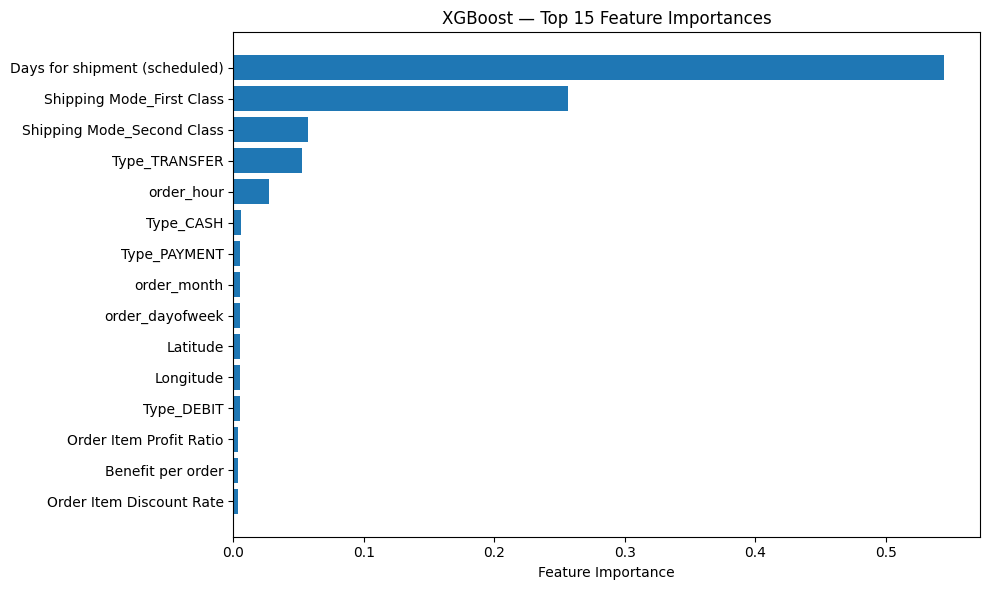


FINAL COMPARISON: GNN vs XGBoost
Metric                       GNN (t=0.50)   XGBoost (t=0.40)
------------------------------------------------------------
AUC-ROC                            0.7785             0.7977
Late F1                            0.7012             0.7360
Late Precision                        86%                71%
Late Recall                           59%                76%
Parameters/Complexity         176K params          200 trees

→ XGBoost wins on AUC by 0.0192


In [64]:
# ============================================
# XGBOOST BASELINE (NO GRAPH STRUCTURE)
# ============================================

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

# Use the SAME flat features that go into order nodes
X = df_encoded[all_order_feature_cols].fillna(0).values
y_flat = df_encoded['Late_delivery_risk'].values

# Use the SAME split masks
train_idx = data['order'].train_mask.cpu().numpy()
val_idx = data['order'].val_mask.cpu().numpy()
test_idx = data['order'].test_mask.cpu().numpy()

X_train, y_train = X[train_idx], y_flat[train_idx]
X_val, y_val = X[val_idx], y_flat[val_idx]
X_test, y_test = X[test_idx], y_flat[test_idx]

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    use_label_encoder=False,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predict
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

# Evaluate at both thresholds
print("XGBOOST THRESHOLD SWEEP")
print("-" * 65)
for t in [0.35, 0.40, 0.45, 0.50]:
    xgb_pred = (xgb_pred_proba > t).astype(int)
    report = classification_report(y_test, xgb_pred, target_names=['On Time', 'Late'], output_dict=True)
    print(f"t={t:.2f} | Late P={report['Late']['precision']:.2f} "
          f"R={report['Late']['recall']:.2f} F1={report['Late']['f1-score']:.2f} | "
          f"Acc={report['accuracy']:.2f}")

# Detailed results at 0.50
xgb_pred_50 = (xgb_pred_proba > 0.4).astype(int)
xgb_f1_50 = f1_score(y_test, xgb_pred_50)

print(f"\n{'='*50}")
print(f"XGBOOST DETAILED RESULTS (threshold = 0.40)")
print(f"{'='*50}")
print(f"AUC-ROC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred_50, target_names=['On Time', 'Late']))

cm_xgb = confusion_matrix(y_test, xgb_pred_50)
print(f"Confusion Matrix:")
print(f"  {'':>12} Pred On-Time  Pred Late")
print(f"  Actual On-Time  {cm_xgb[0][0]:>8}     {cm_xgb[0][1]:>8}")
print(f"  Actual Late     {cm_xgb[1][0]:>8}     {cm_xgb[1][1]:>8}")

# Feature importance
import matplotlib.pyplot as plt
import numpy as np

feat_imp = xgb_model.feature_importances_
feat_names = all_order_feature_cols
sorted_idx = np.argsort(feat_imp)[::-1][:15]  # top 15

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feat_imp[sorted_idx][::-1])
plt.yticks(range(len(sorted_idx)), [feat_names[i] for i in sorted_idx][::-1])
plt.xlabel('Feature Importance')
plt.title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

# ============================================
# FINAL COMPARISON: GNN vs XGBoost
# ============================================

print(f"\n{'='*60}")
print(f"FINAL COMPARISON: GNN vs XGBoost")
print(f"{'='*60}")
print(f"{'Metric':<25} {'GNN (t=0.50)':>15} {'XGBoost (t=0.40)':>18}")
print(f"{'-'*60}")
print(f"{'AUC-ROC':<25} {0.7785:>15.4f} {xgb_auc:>18.4f}")
print(f"{'Late F1':<25} {0.7012:>15.4f} {xgb_f1_50:>18.4f}")
print(f"{'Late Precision':<25} {'86%':>15} {classification_report(y_test, xgb_pred_50, target_names=['On Time', 'Late'], output_dict=True)['Late']['precision']*100:>17.0f}%")
print(f"{'Late Recall':<25} {'59%':>15} {classification_report(y_test, xgb_pred_50, target_names=['On Time', 'Late'], output_dict=True)['Late']['recall']*100:>17.0f}%")
print(f"{'Parameters/Complexity':<25} {'176K params':>15} {'200 trees':>18}")
print(f"\n→ {'GNN wins' if 0.7785 > xgb_auc else 'XGBoost wins'} on AUC by {abs(0.7785 - xgb_auc):.4f}")
